This is a gallery of basic examples showing how to use the plotting library.
In general, you'll have to manually. look up the title ID for each title in `data_playstation.csv` or `data_xbox.csv` files

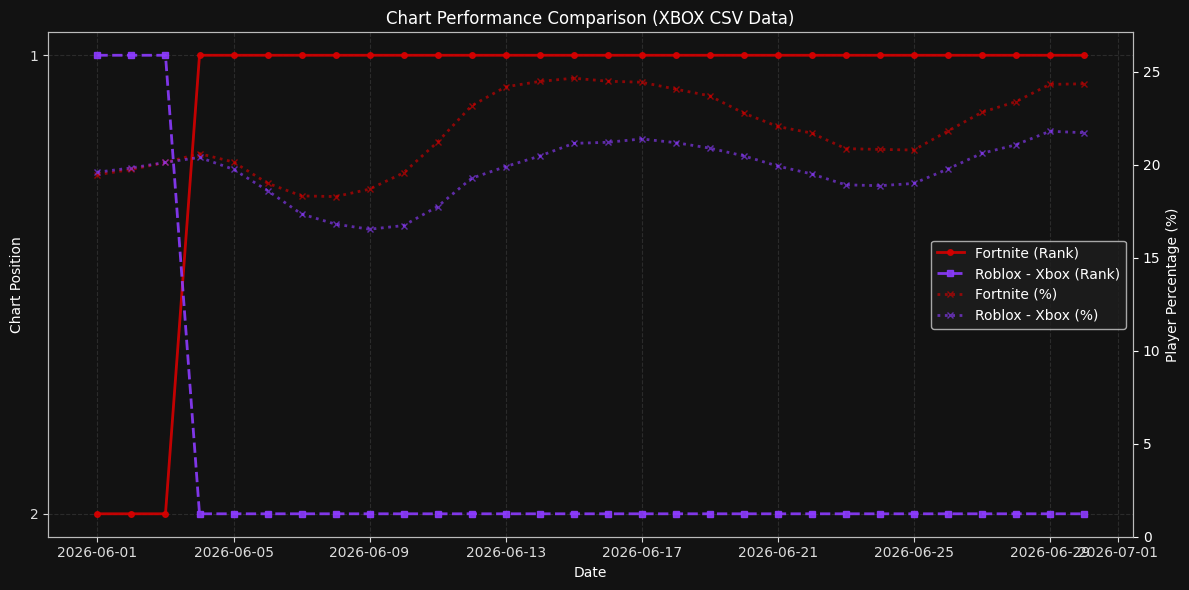

In [1]:
# example 1 - Fortnite vs Roblox on Xbox in June 2026

from plotting.csv_plotter import CSVPlotter # class that compares titles on the same platform
from plotting.plotting_config import PlotStyle

style = PlotStyle(double_y=True) 
#double_y means we'll looking to show not only the positions, but also what percentage of sampled players each title attracted

plotter = CSVPlotter(platform="xbox") # defaults to the 7 days trailing rankings

plotter.compare_titles(
    [
        "267695549", # title ID for Fortnite
        "342226876", # title ID for Roblox
    ], 
    time_span=["2026-06-01", "2026-06-30"], # specifies the date range, otherwise it would plot the entire history of each title
    style=style,
)

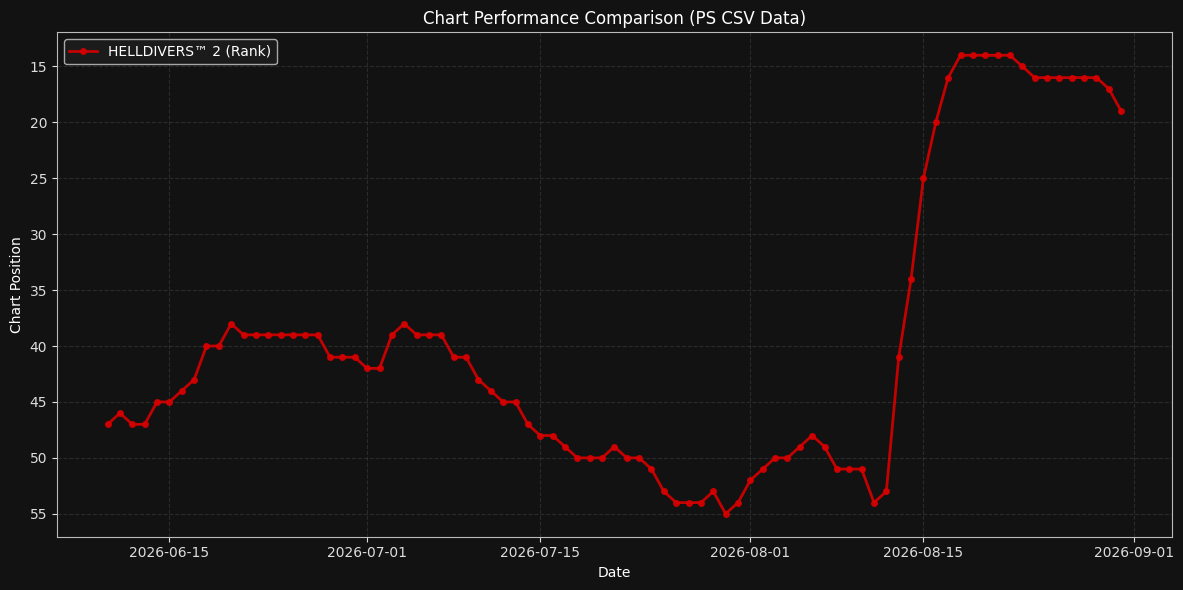

In [2]:
# example 2 - Helldivers 2 on Playstation, just positions

plotter = CSVPlotter(platform="ps")

plotter.compare_titles(["10000657"])

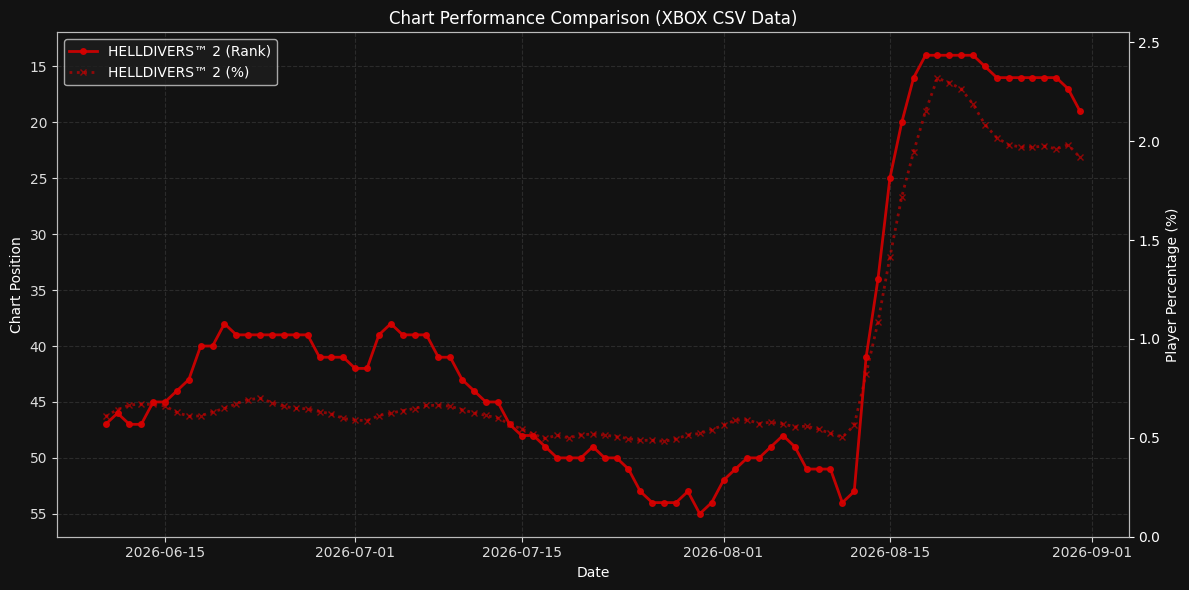

In [3]:
# example 3 - same thing, but we're adding percentage of players
plotter.compare_titles(["10000657"], style=style)

# thus, you can see that the number of players jumped roughly 4x
# after the game got the update/got added to PS+ on August 12th
# (assuming nearly constant active userbase)

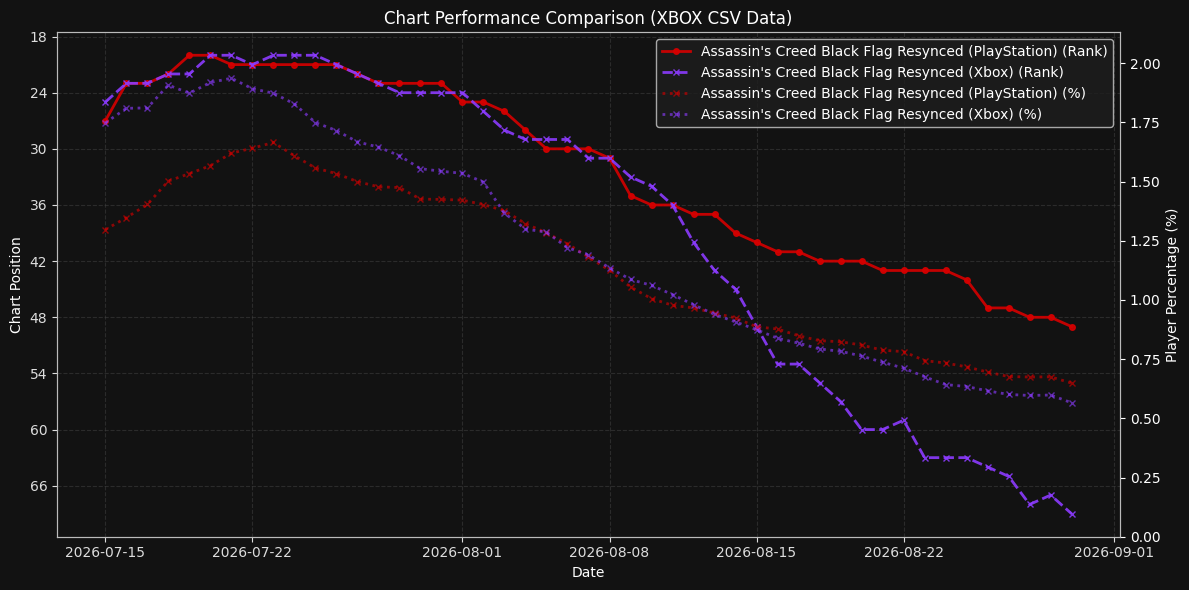

In [4]:
# example 3 - Assassin's Creed Black Flag Resynced on PS5 vs Xbox

from plotting.versus_plotter import (
    VersusPlotter,
)  # class that compares titles on Playstation and Xbox

plotter = VersusPlotter()

plotter.compare_platforms(
    "10013987",  # title ID for AC4R on Playstation
    "1661962317",  # title ID for AC4R on Xbox
    time_span=["2026-07-15", "2026-08-30"],
    style=style,  # the previously defined style gets reused here
)

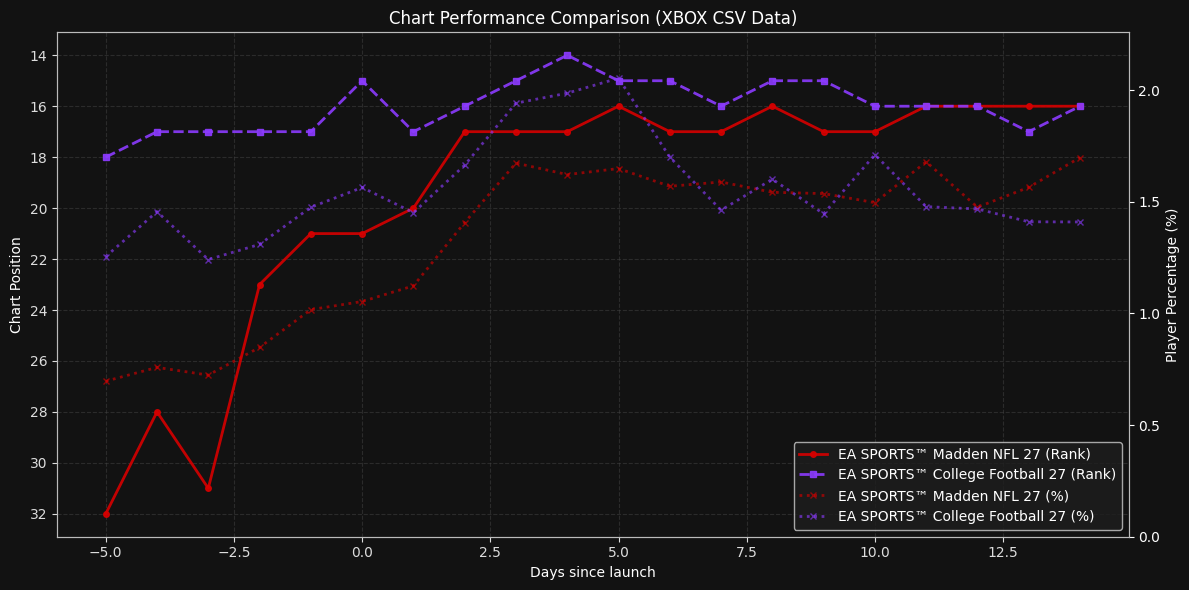

In [5]:
# example 4 - daily activity of College Football 27 vs Madden NFL 27 on Xbox,
# launch aligned in the advanced access period and the first two weeks after launch
plotter = CSVPlotter(platform="xbox", chart_type="daily")

plotter.compare_titles(
    ["1962870476", "1674575880"],
    launch_aligned=True,
    time_span=[-5, 14],  # time interval in days since launch
    style=style,
)

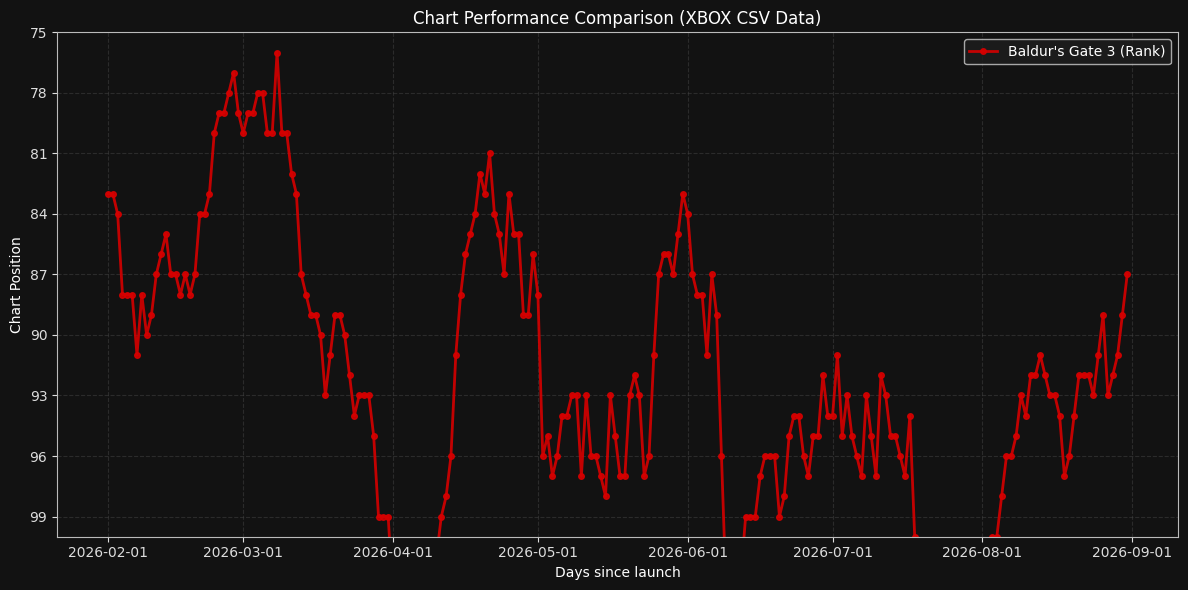

In [6]:
# you can heavily customize the plots by writing custom functions modifying matplotlib's axis objects

plotter = CSVPlotter(platform="xbox")

def hook(ax):
    ax.set_ylim(100,75) # limits the y-axis range to 100-75

style.custom_hook=hook
style.double_y=False

plotter.compare_titles(
    ["1975246356"],
    style=style,
)
